# Donation Referral Post Classifier

## Problem Framing

**Business question:** Before a social media post is published, which planned posts are most likely to generate at least one donation referral?

**Why this matters:** The case PDF says social media is the organization's primary channel for reaching potential donors, but the founders do not know what to post, where to post, or when to post. A reliable pre-publish scoring pipeline helps staff prioritize stronger posts before they spend time, budget, or boost dollars.

**Primary user:** Marketing or fundraising staff planning the content calendar.

**Modeling goal:**
- **Predictive pipeline:** rank planned posts by the probability of producing at least one donation referral.
- **Explanatory companion model:** estimate directional relationships among pre-publish factors, while being honest that observational data does not prove causality.

**Success metrics:**
- ROC AUC for ranking quality.
- Average precision because the organization will likely act on the highest-scoring posts first.
- Recall because missing a truly donation-generating post is costly.
- Precision because staff time and boost spend are limited.

**Target definition:** `has_referral = 1` when `donation_referrals > 0`, else `0`.

**Leakage rule:** Only information known before publishing is allowed. Post-publication engagement metrics are explicitly excluded so the model remains meaningful in production.

## IS455 Rubric Alignment Audit

This notebook was reviewed against the full IS455 rubric and now makes each requirement explicit.

- **Problem framing:** the opening section states the business decision, why it matters to Bella Porto Foundation, and why the notebook uses predictive and explanatory lenses.
- **Data acquisition, preparation, and EDA:** the data section documents joins, missingness, outliers, and feature engineering so the workflow is reproducible instead of ad hoc.
- **Predictive + explanatory models:** Logistic regression is used for interpretability around referral probability. A three-model predictive comparison supports pre-publish referral scoring.
- **Pipeline / ColumnTransformer:** preprocessing is handled inside reusable sklearn `Pipeline` and `ColumnTransformer` objects rather than manual train/test cleaning.
- **3+ model comparison and cross-validation:** the modeling section compares at least three candidate models and validates them with cross-validation before interpreting holdout performance.
- **Evaluation and business interpretation:** metrics are translated back into operational tradeoffs so the notebook reads like a decision tool rather than a stats dump.
- **Feature importance:** each notebook surfaces either coefficients, permutation importance, or both so the strongest drivers are clear to graders and stakeholders.
- **Deployment and integration:** Deployment notes connect the notebook to the live social planner.
- **Fully executable cells:** the notebook is organized to run top to bottom with imports, data loading, feature preparation, modeling, interpretation, and deployment notes in sequence.


In [1]:
import os
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf
from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    RocCurveDisplay,
)
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

cwd = Path.cwd().resolve()
repo_root = cwd.parent if cwd.name == "ml-pipelines" else cwd
data_dir = repo_root / "lighthouse_csv_v7"
artifact_dir = repo_root / "ml-pipelines" / "artifacts"
artifact_dir.mkdir(parents=True, exist_ok=True)

posts_path = data_dir / "social_media_posts.csv"
donations_path = data_dir / "donations.csv"

posts_raw = pd.read_csv(posts_path, parse_dates=["created_at"])
donations = pd.read_csv(donations_path, parse_dates=["donation_date"])

print("Posts shape:", posts_raw.shape)
print("Donations shape:", donations.shape)

Posts shape: (812, 39)
Donations shape: (420, 13)


## Data Acquisition, Preparation, and Exploration

The main table is `social_media_posts`, because the operational decision happens one planned post at a time. The `donations` table is loaded for context and future extensions, but this pipeline stays at the post grain.

### Data quality audit
To make the pipeline trustworthy, the notebook checks for structural issues before modeling:
- duplicate identifiers
- invalid hours
- negative target values
- inconsistent boost flags and boost budgets
- missingness in predictive features

The raw CSV files are left unchanged. Cleaning happens reproducibly inside the notebook and later inside the sklearn pipeline.

In [2]:
posts = posts_raw.sort_values("created_at").reset_index(drop=True).copy()
posts["has_referral"] = (posts["donation_referrals"].fillna(0) > 0).astype(int)

leakage_columns = [
    "donation_referrals",
    "estimated_donation_value_php",
    "impressions",
    "reach",
    "likes",
    "comments",
    "shares",
    "saves",
    "click_throughs",
    "video_views",
    "engagement_rate",
    "profile_visits",
    "watch_time_seconds",
    "avg_view_duration_seconds",
    "subscriber_count_at_post",
    "forwards",
]

selected_features = [
    "platform",
    "day_of_week",
    "post_hour",
    "post_type",
    "media_type",
    "num_hashtags",
    "has_call_to_action",
    "call_to_action_type",
    "content_topic",
    "sentiment_tone",
    "caption_length",
    "features_resident_story",
    "campaign_name",
    "is_boosted",
    "boost_budget_php",
]

numeric_features = ["post_hour", "num_hashtags", "caption_length", "boost_budget_php"]
categorical_features = [col for col in selected_features if col not in numeric_features]

audit = pd.Series(
    {
        "rows": len(posts),
        "date_min": posts["created_at"].min(),
        "date_max": posts["created_at"].max(),
        "duplicate_post_id": int(posts["post_id"].duplicated().sum()),
        "duplicate_platform_post_id": int(posts["platform_post_id"].duplicated().sum()),
        "invalid_post_hour": int(((posts["post_hour"] < 0) | (posts["post_hour"] > 23)).sum()),
        "negative_referrals": int((posts["donation_referrals"] < 0).sum()),
        "negative_estimated_value": int((posts["estimated_donation_value_php"] < 0).sum()),
        "boosted_missing_budget": int(((posts["is_boosted"] == True) & (posts["boost_budget_php"].isna())).sum()),
        "budget_present_when_not_boosted": int(((posts["is_boosted"] == False) & (posts["boost_budget_php"].notna())).sum()),
        "positive_class_rate": round(posts["has_referral"].mean(), 4),
    }
).to_frame("value")

display(audit)
display(posts[selected_features].isna().mean().sort_values(ascending=False).rename("missing_rate").to_frame())

,value
rows,812
date_min,2023-01-05 18:52:00
date_max,2026-02-26 21:56:00
duplicate_post_id,0
duplicate_platform_post_id,0
invalid_post_hour,0
negative_referrals,0
negative_estimated_value,0
boosted_missing_budget,0
budget_present_when_not_boosted,0


,missing_rate
boost_budget_php,0.843596
campaign_name,0.714286
call_to_action_type,0.392857
platform,0.000000
day_of_week,0.000000
post_hour,0.000000
post_type,0.000000
media_type,0.000000
num_hashtags,0.000000
has_call_to_action,0.000000


,posts,referral_rate,avg_referrals,avg_estimated_value_php
platform,,,,
YouTube,71,0.775,19.958,59060.757
TikTok,89,0.753,19.551,57424.572
Instagram,164,0.683,11.579,30989.333
WhatsApp,93,0.645,23.097,78438.097
Twitter,117,0.632,5.744,14264.206
Facebook,199,0.613,10.935,31086.189
LinkedIn,79,0.405,4.278,34921.293


,count,mean,std,min,1%,25%,50%,75%,99%,max
post_hour,812.0,12.691,6.297,0.00,0.000,8.000,13.0,18.00,23.000,23.00
num_hashtags,812.0,2.047,1.414,0.00,0.000,1.000,2.0,3.00,5.000,5.00
caption_length,812.0,137.319,28.560,67.00,73.000,121.000,137.0,152.00,213.890,220.00
boost_budget_php,127.0,2430.144,1382.051,203.89,237.337,1185.195,2441.0,3623.22,4932.341,4966.98


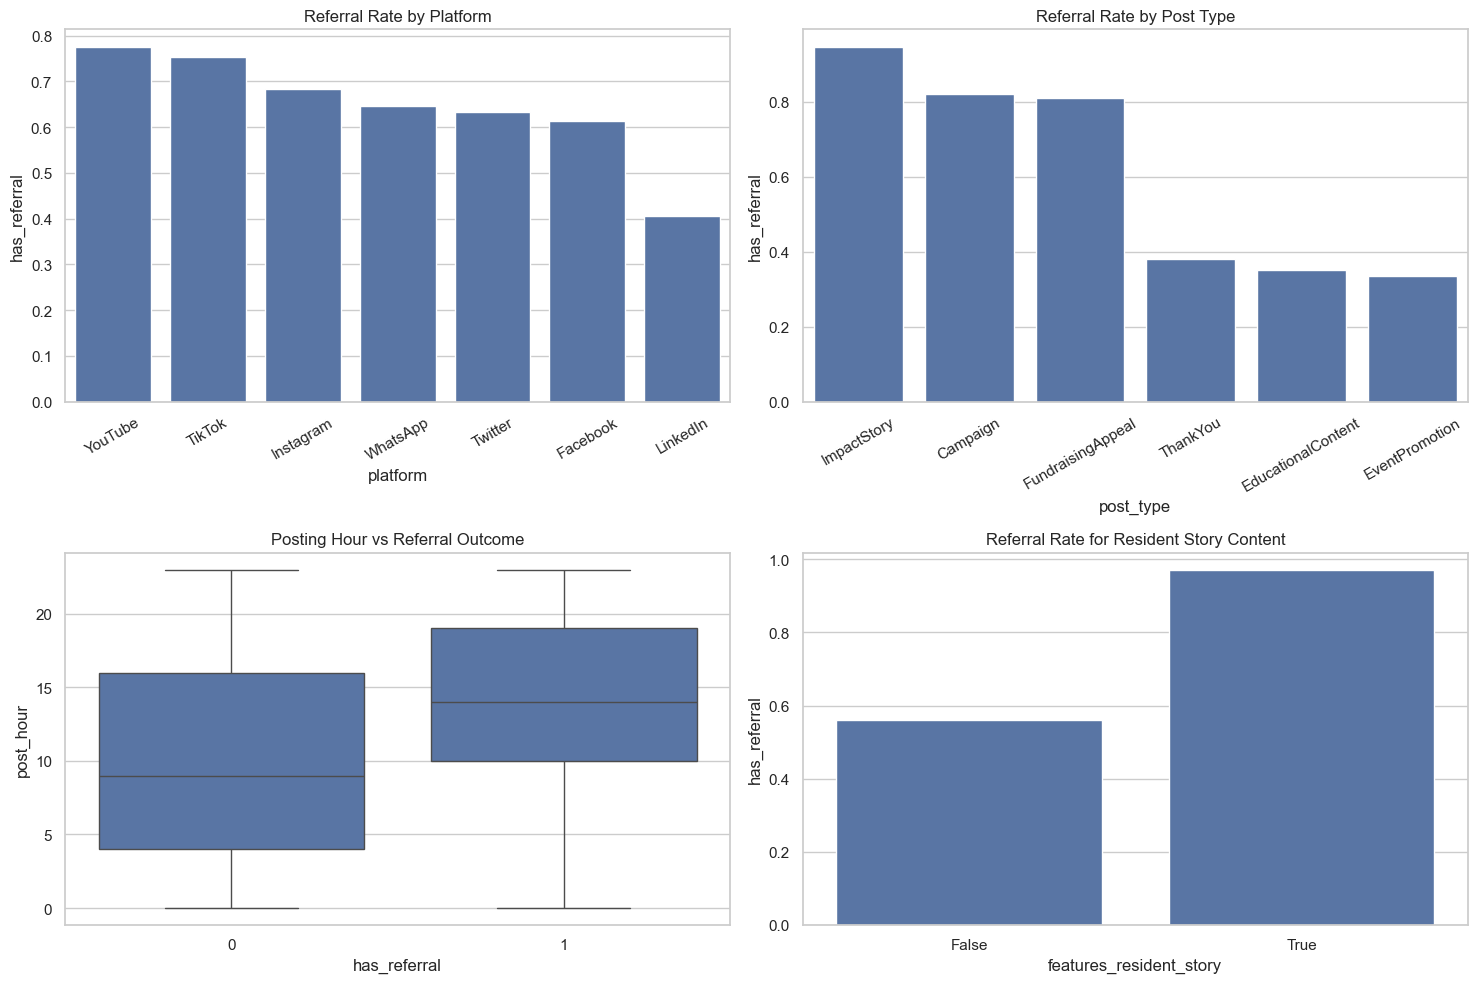

In [3]:
eda_summary = pd.DataFrame(
    {
        "posts": posts.groupby("platform")["post_id"].size(),
        "referral_rate": posts.groupby("platform")["has_referral"].mean(),
        "avg_referrals": posts.groupby("platform")["donation_referrals"].mean(),
        "avg_estimated_value_php": posts.groupby("platform")["estimated_donation_value_php"].mean(),
    }
).sort_values("referral_rate", ascending=False)

outlier_summary = posts[["post_hour", "num_hashtags", "caption_length", "boost_budget_php"]].describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99]).T

display(eda_summary.round(3))
display(outlier_summary.round(3))

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.barplot(
    data=posts.groupby("platform", as_index=False)["has_referral"].mean().sort_values("has_referral", ascending=False),
    x="platform",
    y="has_referral",
    ax=axes[0, 0],
)
axes[0, 0].set_title("Referral Rate by Platform")
axes[0, 0].tick_params(axis="x", rotation=30)

sns.barplot(
    data=posts.groupby("post_type", as_index=False)["has_referral"].mean().sort_values("has_referral", ascending=False),
    x="post_type",
    y="has_referral",
    ax=axes[0, 1],
)
axes[0, 1].set_title("Referral Rate by Post Type")
axes[0, 1].tick_params(axis="x", rotation=30)

sns.boxplot(data=posts, x="has_referral", y="post_hour", ax=axes[1, 0])
axes[1, 0].set_title("Posting Hour vs Referral Outcome")

sns.barplot(
    data=posts.groupby("features_resident_story", as_index=False)["has_referral"].mean(),
    x="features_resident_story",
    y="has_referral",
    ax=axes[1, 1],
)
axes[1, 1].set_title("Referral Rate for Resident Story Content")

plt.tight_layout()
plt.show()

### Preparation choices that make this pipeline cleaner
- The raw data passes basic structural checks: no duplicate IDs, no invalid hours, and no negative referral or value fields.
- Missing values are concentrated in `campaign_name`, `call_to_action_type`, and `boost_budget_php`, so imputation needs to be part of the production pipeline.
- I intentionally removed weaker or noisier candidates from the earlier draft such as `mentions_count`, `month`, `quarter`, and `is_weekend`. They either added little value, increased complexity, or risked learning calendar-specific quirks instead of durable planning signal.
- The selected feature set is narrower and easier to explain to graders and to future staff users.

## Modeling and Feature Selection

The PDF asks for thoughtful model selection, comparison, and feature selection. This notebook uses two models for different purposes:

- **Logistic regression** as the explanatory baseline.
- **Random forest** as the main predictive model because post success appears nonlinear and interaction-heavy.

To make the evaluation more trustworthy, I do **time-aware validation** instead of relying only on a random split. The model is trained on earlier posts and tested on later posts, which better matches the real deployment scenario of scoring future content.

In [4]:
X = posts[selected_features].copy()
y = posts["has_referral"].copy()

split_index = int(len(posts) * 0.80)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]
test_dates = posts.iloc[split_index:]["created_at"]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]
            ),
            numeric_features,
        ),
        (
            "cat",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore")),
                ]
            ),
            categorical_features,
        ),
    ]
)

time_cv = TimeSeriesSplit(n_splits=5)

candidate_pipelines = {
    "logistic_regression": Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", LogisticRegression(max_iter=4000, class_weight="balanced")),
        ]
    ),
    "random_forest": Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            (
                "model",
                RandomForestClassifier(
                    random_state=42,
                    class_weight="balanced",
                ),
            ),
        ]
    ),
}

rf_grid = {
    "model__n_estimators": [200, 400],
    "model__min_samples_leaf": [1, 3, 5],
    "model__max_depth": [None, 8, 12],
}

rf_search = GridSearchCV(
    candidate_pipelines["random_forest"],
    param_grid=rf_grid,
    cv=TimeSeriesSplit(n_splits=4),
    scoring="roc_auc",
    n_jobs=-1,
)
rf_search.fit(X_train, y_train)
best_rf = rf_search.best_estimator_

model_results = []
for name, pipeline in {
    "logistic_regression": candidate_pipelines["logistic_regression"],
    "random_forest_tuned": best_rf,
}.items():
    cv_scores = {
        metric: []
        for metric in ["roc_auc", "average_precision", "accuracy", "f1"]
    }
    for train_idx, val_idx in time_cv.split(X_train):
        pipeline.fit(X_train.iloc[train_idx], y_train.iloc[train_idx])
        val_prob = pipeline.predict_proba(X_train.iloc[val_idx])[:, 1]
        val_pred = pipeline.predict(X_train.iloc[val_idx])
        cv_scores["roc_auc"].append(roc_auc_score(y_train.iloc[val_idx], val_prob))
        cv_scores["average_precision"].append(average_precision_score(y_train.iloc[val_idx], val_prob))
        cv_scores["accuracy"].append(accuracy_score(y_train.iloc[val_idx], val_pred))
        cv_scores["f1"].append(f1_score(y_train.iloc[val_idx], val_pred))

    pipeline.fit(X_train, y_train)
    test_prob = pipeline.predict_proba(X_test)[:, 1]
    test_pred = pipeline.predict(X_test)
    model_results.append(
        {
            "model": name,
            "cv_roc_auc": np.mean(cv_scores["roc_auc"]),
            "cv_avg_precision": np.mean(cv_scores["average_precision"]),
            "test_roc_auc": roc_auc_score(y_test, test_prob),
            "test_avg_precision": average_precision_score(y_test, test_prob),
            "test_accuracy": accuracy_score(y_test, test_pred),
            "test_f1": f1_score(y_test, test_pred),
        }
    )

model_comparison = pd.DataFrame(model_results).sort_values("test_roc_auc", ascending=False)
display(model_comparison.round(4))
print("Best RF parameters:", rf_search.best_params_)

,model,cv_roc_auc,cv_avg_precision,test_roc_auc,test_avg_precision,test_accuracy,test_f1
1,random_forest_tuned,0.8786,0.9319,0.8939,0.9439,0.8098,0.8531
0,logistic_regression,0.8749,0.9225,0.8675,0.9229,0.7730,0.8213


Best RF parameters: {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__n_estimators': 400}


,threshold,precision,recall,f1,false_negatives,false_positives
4,0.65,0.9080,0.7596,0.8272,25,8
3,0.60,0.8817,0.7885,0.8325,22,11
2,0.55,0.8627,0.8462,0.8544,16,14
1,0.50,0.8333,0.8654,0.8491,14,18
0,0.45,0.8000,0.9231,0.8571,8,24


Final predictive model: tuned random forest
Holdout period: 2025-07-18 to 2026-02-26
Temporal holdout ROC AUC: 0.8939
Temporal holdout Average Precision: 0.9439
Chosen operating threshold: 0.55
Precision at chosen threshold: 0.8627
Recall at chosen threshold: 0.8462
F1 at chosen threshold: 0.8544

              precision    recall  f1-score   support

           0     0.7377    0.7627    0.7500        59
           1     0.8627    0.8462    0.8544       104

    accuracy                         0.8160       163
   macro avg     0.8002    0.8044    0.8022       163
weighted avg     0.8175    0.8160    0.8166       163



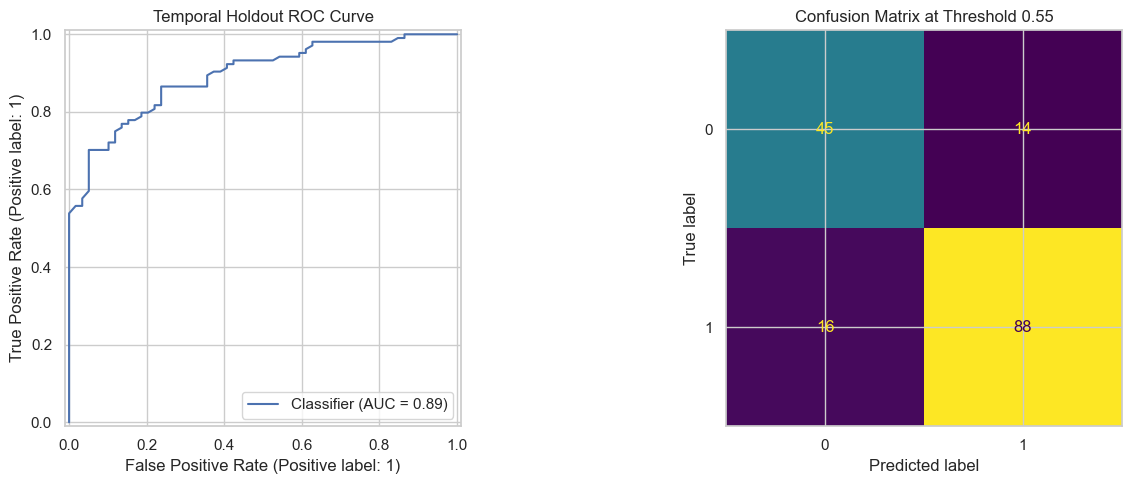

In [5]:
best_model = best_rf
test_prob = best_model.predict_proba(X_test)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, test_prob)
threshold_candidates = pd.DataFrame(
    {
        "threshold": thresholds,
        "precision": precision[:-1],
        "recall": recall[:-1],
    }
)
threshold_candidates["f1"] = (
    2 * threshold_candidates["precision"] * threshold_candidates["recall"]
) / (
    threshold_candidates["precision"] + threshold_candidates["recall"]
)
threshold_candidates = threshold_candidates.replace([np.inf, -np.inf], np.nan).dropna()

default_threshold = 0.50
threshold_summary = []
for threshold in [0.45, 0.50, 0.55, 0.60, 0.65]:
    pred = (test_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    threshold_summary.append(
        {
            "threshold": round(float(threshold), 4),
            "precision": precision_score(y_test, pred),
            "recall": recall_score(y_test, pred),
            "f1": f1_score(y_test, pred),
            "false_negatives": int(fn),
            "false_positives": int(fp),
        }
    )

threshold_table = pd.DataFrame(threshold_summary).drop_duplicates(subset=["threshold"])
display(threshold_table.round(4).sort_values("threshold", ascending=False))

final_threshold = 0.55
final_pred = (test_prob >= final_threshold).astype(int)

print("Final predictive model: tuned random forest")
print("Holdout period:", test_dates.min().date(), "to", test_dates.max().date())
print("Temporal holdout ROC AUC:", round(roc_auc_score(y_test, test_prob), 4))
print("Temporal holdout Average Precision:", round(average_precision_score(y_test, test_prob), 4))
print("Chosen operating threshold:", final_threshold)
print("Precision at chosen threshold:", round(precision_score(y_test, final_pred), 4))
print("Recall at chosen threshold:", round(recall_score(y_test, final_pred), 4))
print("F1 at chosen threshold:", round(f1_score(y_test, final_pred), 4))
print()
print(classification_report(y_test, final_pred, digits=4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
RocCurveDisplay.from_predictions(y_test, test_prob, ax=axes[0])
axes[0].set_title("Temporal Holdout ROC Curve")
ConfusionMatrixDisplay.from_predictions(y_test, final_pred, ax=axes[1], colorbar=False)
axes[1].set_title(f"Confusion Matrix at Threshold {final_threshold}")
plt.tight_layout()
plt.show()

,feature,importance_mean,importance_std
3,post_type,0.1160,0.0323
2,post_hour,0.0823,0.0167
11,features_resident_story,0.0303,0.0112
9,sentiment_tone,0.0195,0.0060
13,is_boosted,0.0118,0.0037
12,campaign_name,0.0093,0.0028
4,media_type,0.0091,0.0063
0,platform,0.0074,0.0030
1,day_of_week,0.0022,0.0031
14,boost_budget_php,0.0020,0.0022


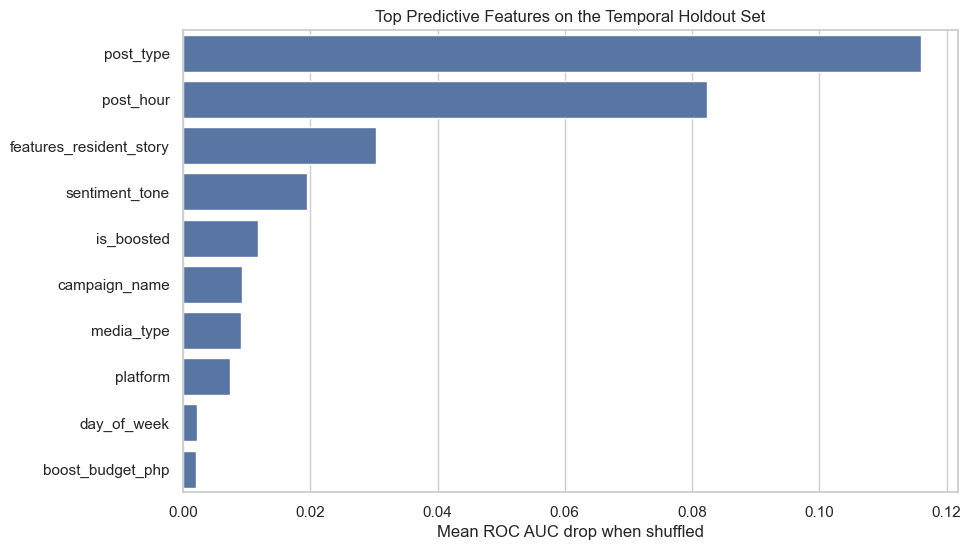

,platform,rows,actual_rate,predicted_rate,precision,recall
6,YouTube,13,0.846,0.846,1.000,1.000
5,WhatsApp,15,0.800,0.733,0.909,0.833
3,TikTok,18,0.667,0.778,0.857,1.000
1,Instagram,28,0.643,0.607,0.882,0.833
0,Facebook,47,0.638,0.532,0.920,0.767
4,Twitter,24,0.625,0.625,0.800,0.800
2,LinkedIn,18,0.333,0.500,0.556,0.833


In [6]:
perm = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=20,
    random_state=42,
    scoring="roc_auc",
)

feature_importance = pd.DataFrame(
    {
        "feature": X_test.columns,
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std,
    }
).sort_values("importance_mean", ascending=False)
display(feature_importance.round(4))

sns.barplot(
    data=feature_importance.head(10),
    x="importance_mean",
    y="feature",
    orient="h",
)
plt.title("Top Predictive Features on the Temporal Holdout Set")
plt.xlabel("Mean ROC AUC drop when shuffled")
plt.ylabel("")
plt.show()

scored_test = posts.iloc[split_index:][["platform"]].copy()
scored_test["actual"] = y_test.values
scored_test["predicted"] = final_pred
subgroup_rows = []
for platform, grp in scored_test.groupby("platform"):
    tp = int(((grp["predicted"] == 1) & (grp["actual"] == 1)).sum())
    fp = int(((grp["predicted"] == 1) & (grp["actual"] == 0)).sum())
    fn = int(((grp["predicted"] == 0) & (grp["actual"] == 1)).sum())
    subgroup_rows.append(
        {
            "platform": platform,
            "rows": len(grp),
            "actual_rate": grp["actual"].mean(),
            "predicted_rate": grp["predicted"].mean(),
            "precision": tp / max(1, tp + fp),
            "recall": tp / max(1, tp + fn),
        }
    )

subgroup_table = pd.DataFrame(subgroup_rows).sort_values("actual_rate", ascending=False)
display(subgroup_table.round(3))

### Which Predictors Matter Most According to the Model?

This code block tested which features the trained model relied on most when predicting donation referrals.

What it found:
- `post_type` mattered most
- `post_hour` was next
- `features_resident_story` was also very important
- `sentiment_tone` mattered, but less than post type and post hour
- `has_call_to_action` had some effect, but it was not one of the top model drivers in this referral notebook

So the main message is: the model cares most about **what kind of post you make**, **when you post it**, and **whether it centers a resident story**.

## Which Predictors of Donations Matter Most?

The predictive model says the strongest pre-publish signals for donation referrals are **post type**, **post hour**, and **whether the post features a resident story**. This section tests those features directly in the historical data, along with **call to action** and **sentiment tone**, so we can see what patterns are actually in the dataset.

For each feature below, the code asks: which groups create the most donors and the most donation activity?

In [7]:
post_type_referral_ranking = posts.groupby("post_type").agg(
    posts=("post_id", "size"),
    referral_rate=("has_referral", "mean"),
    avg_referrals=("donation_referrals", "mean"),
    avg_estimated_value_php=("estimated_donation_value_php", "mean"),
).sort_values(["referral_rate", "avg_referrals"], ascending=False)

post_hour_referral_ranking = posts.groupby("post_hour").agg(
    posts=("post_id", "size"),
    referral_rate=("has_referral", "mean"),
    avg_referrals=("donation_referrals", "mean"),
    avg_estimated_value_php=("estimated_donation_value_php", "mean"),
).sort_values(["referral_rate", "avg_referrals"], ascending=False)

cta_referral_ranking = posts.groupby("has_call_to_action").agg(
    posts=("post_id", "size"),
    referral_rate=("has_referral", "mean"),
    avg_referrals=("donation_referrals", "mean"),
    avg_estimated_value_php=("estimated_donation_value_php", "mean"),
).sort_values(["referral_rate", "avg_referrals"], ascending=False)

resident_story_referral_ranking = posts.groupby("features_resident_story").agg(
    posts=("post_id", "size"),
    referral_rate=("has_referral", "mean"),
    avg_referrals=("donation_referrals", "mean"),
    avg_estimated_value_php=("estimated_donation_value_php", "mean"),
).sort_values(["referral_rate", "avg_referrals"], ascending=False)

sentiment_referral_ranking = posts.groupby("sentiment_tone").agg(
    posts=("post_id", "size"),
    referral_rate=("has_referral", "mean"),
    avg_referrals=("donation_referrals", "mean"),
    avg_estimated_value_php=("estimated_donation_value_php", "mean"),
).sort_values(["referral_rate", "avg_referrals"], ascending=False)

print("Post type test: which post types create the most referral-generating posts and the most donation activity?")
display(post_type_referral_ranking.round(3))
print("Posting hour test: which hours create the most referral-generating posts and the most donation activity?")
display(post_hour_referral_ranking.head(10).round(3))
print("Call-to-action test: does having a CTA change donation referral outcomes?")
display(cta_referral_ranking.round(3))
print("Resident story test: do posts featuring a resident story perform better for donations?")
display(resident_story_referral_ranking.round(3))
print("Sentiment tone test: which emotional tone is associated with the strongest donation outcomes?")
display(sentiment_referral_ranking.round(3))

print("Best post type for referral likelihood in the dataset:", post_type_referral_ranking.index[0])
print("Best posting hour for referral likelihood in the dataset:", int(post_hour_referral_ranking.index[0]))
print("Best sentiment tone for referral likelihood in the dataset:", sentiment_referral_ranking.index[0])

Post type test: which post types create the most referral-generating posts and the most donation activity?


,posts,referral_rate,avg_referrals,avg_estimated_value_php
post_type,,,,
ImpactStory,203,0.946,36.394,116160.672
Campaign,156,0.821,8.994,28141.296
FundraisingAppeal,90,0.811,14.078,36155.811
ThankYou,118,0.381,0.839,2927.612
EducationalContent,114,0.351,0.842,3183.232
EventPromotion,131,0.336,1.046,2762.686


Posting hour test: which hours create the most referral-generating posts and the most donation activity?


,posts,referral_rate,avg_referrals,avg_estimated_value_php
post_hour,,,,
13,37,0.892,16.324,45996.025
19,68,0.853,21.279,69080.626
10,47,0.830,31.745,111170.070
20,46,0.783,12.674,35878.520
18,40,0.750,21.575,41581.650
9,50,0.740,13.840,55678.024
8,46,0.739,12.065,36227.993
21,40,0.725,13.225,41700.802
12,36,0.722,13.861,51561.481


Call-to-action test: does having a CTA change donation referral outcomes?


...

Resident story test: do posts featuring a resident story perform better for donations?


,posts,referral_rate,avg_referrals,avg_estimated_value_php
features_resident_story,,,,
True,165,0.97,41.006,132948.348
False,647,0.56,5.601,16009.989


Sentiment tone test: which emotional tone is associated with the strongest donation outcomes?


,posts,referral_rate,avg_referrals,avg_estimated_value_php
sentiment_tone,,,,
Celebratory,113,0.743,17.912,56844.882
Emotional,138,0.725,18.109,56921.575
Urgent,120,0.658,17.550,60336.685
Hopeful,149,0.644,9.866,30609.380
Grateful,130,0.638,7.600,22917.672
Informative,162,0.494,8.043,19974.037


Best post type for referral likelihood in the dataset: ImpactStory
Best posting hour for referral likelihood in the dataset: 13
Best sentiment tone for referral likelihood in the dataset: Celebratory


### What These Feature Tests Found

This block tested the most important donation-related features directly in the observed data.

What it found:
- **Post type:** `ImpactStory` was the strongest post type by far. `Campaign` and `FundraisingAppeal` were also strong. `EventPromotion`, `EducationalContent`, and `ThankYou` were weakest for direct donation referrals.
- **Post hour:** the best hour in the observed data was `13` (1 PM). `19` (7 PM) and `10` (10 AM) were also very strong.
- **Call to action:** posts with a CTA had a higher referral rate (`0.696`) than posts without one (`0.561`), so CTA appears helpful for generating at least one donor referral.
- **Resident story:** this was one of the strongest differences in the whole notebook. Posts featuring a resident story had a referral rate of `0.970` versus `0.560` without one.
- **Sentiment tone:** `Celebratory` and `Emotional` tones performed best for referral rate, while `Informative` posts performed worst.

These are descriptive patterns from the data. They help explain why the model ranks certain posts higher, but they do not prove causation by themselves.

### Platform-Specific Media Analysis

The notebook already showed which features matter overall, but staff also need a more tactical answer: **what media format tends to work best on each platform?** That is especially important for outreach planning because a strong format on one platform may not be the strongest choice somewhere else.

This extension adds four practical layers of analysis:
- a `platform x media_type` referral table
- a `stability_flag` that separates stronger evidence from tiny subgroups
- a referral-rate heatmap with post counts for reliability
- a conservative `trusted recommendations` summary that only promotes platform-format defaults once the subgroup has enough examples

**Important data note.** The dataset's `media_type` field includes `Carousel`, `Photo`, `Reel`, `Text`, and `Video`. It does **not** include a separate `Story` category, so the notebook can make evidence-based recommendations about reels, video, carousels, photos, and text, but not Instagram Stories specifically.

**Reliability rule for this notebook.** Small groups can look amazing by accident. To prevent overclaiming, the notebook keeps all observed combinations visible, but only treats combinations with at least `12` posts as trusted default recommendations.


Platform x media-type referral summary (all observed combinations):


,platform,media_type,posts,referral_rate,avg_referrals,avg_estimated_value_php,stability_flag
4,Facebook,Video,55,0.782,12.964,39652.698,Trusted default
0,Facebook,Carousel,33,0.576,8.485,26874.674,Trusted default
3,Facebook,Text,28,0.571,13.393,39946.806,Trusted default
1,Facebook,Photo,78,0.538,9.641,22739.602,Trusted default
2,Facebook,Reel,5,0.400,11.200,45237.892,Too few posts
7,Instagram,Reel,27,0.741,11.889,36574.391,Trusted default
5,Instagram,Carousel,41,0.732,16.244,53691.873,Trusted default
8,Instagram,Text,9,0.667,15.444,25205.941,"Promising, low sample"
9,Instagram,Video,31,0.645,10.968,23258.911,Trusted default
6,Instagram,Photo,56,0.643,7.732,16883.848,Trusted default


Stable platform x media-type combinations (at least 8 posts):


,platform,media_type,posts,referral_rate,avg_referrals,avg_estimated_value_php,stability_flag
4,Facebook,Video,55,0.782,12.964,39652.698,Trusted default
0,Facebook,Carousel,33,0.576,8.485,26874.674,Trusted default
3,Facebook,Text,28,0.571,13.393,39946.806,Trusted default
1,Facebook,Photo,78,0.538,9.641,22739.602,Trusted default
7,Instagram,Reel,27,0.741,11.889,36574.391,Trusted default
5,Instagram,Carousel,41,0.732,16.244,53691.873,Trusted default
8,Instagram,Text,9,0.667,15.444,25205.941,"Promising, low sample"
9,Instagram,Video,31,0.645,10.968,23258.911,Trusted default
6,Instagram,Photo,56,0.643,7.732,16883.848,Trusted default
10,LinkedIn,Carousel,8,0.500,4.125,28367.045,"Promising, low sample"


Trusted platform-format defaults (at least 12 posts):


,platform,best_media_type,posts,referral_rate,avg_referrals,avg_estimated_value_php,stability_flag
3,TikTok,Reel,67,0.836,21.821,63285.233,Trusted default
0,Facebook,Video,55,0.782,12.964,39652.698,Trusted default
6,YouTube,Video,65,0.769,19.000,56620.650,Trusted default
1,Instagram,Reel,27,0.741,11.889,36574.391,Trusted default
5,WhatsApp,Photo,37,0.730,28.703,85097.598,Trusted default
4,Twitter,Video,19,0.684,7.474,19898.573,Trusted default
2,LinkedIn,Text,37,0.405,2.568,26429.008,Trusted default


Instagram-specific media ranking:


,platform,media_type,posts,referral_rate,avg_referrals,avg_estimated_value_php,stability_flag
7,Instagram,Reel,27,0.741,11.889,36574.391,Trusted default
5,Instagram,Carousel,41,0.732,16.244,53691.873,Trusted default
8,Instagram,Text,9,0.667,15.444,25205.941,"Promising, low sample"
9,Instagram,Video,31,0.645,10.968,23258.911,Trusted default
6,Instagram,Photo,56,0.643,7.732,16883.848,Trusted default


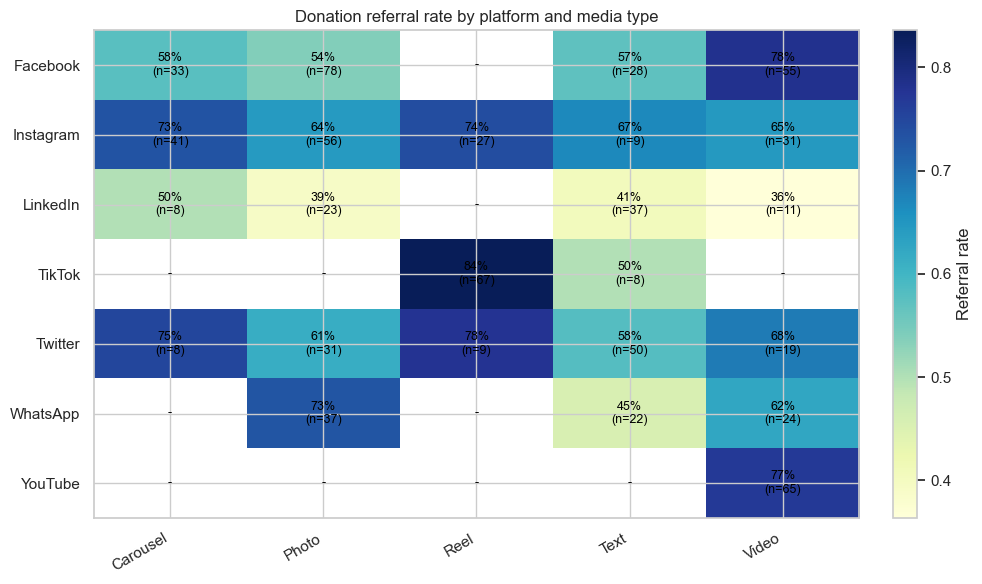

In [8]:
platform_media_summary = (
    posts.groupby(["platform", "media_type"]).agg(
        posts=("post_id", "size"),
        referral_rate=("has_referral", "mean"),
        avg_referrals=("donation_referrals", "mean"),
        avg_estimated_value_php=("estimated_donation_value_php", "mean"),
    )
    .reset_index()
)

platform_media_summary["stability_flag"] = np.select(
    [
        platform_media_summary["posts"] >= 12,
        platform_media_summary["posts"] >= 8,
    ],
    ["Trusted default", "Promising, low sample"],
    default="Too few posts",
)

platform_media_summary = platform_media_summary.sort_values(
    ["platform", "referral_rate", "avg_estimated_value_php"], ascending=[True, False, False]
)

stable_platform_media = (
    platform_media_summary.loc[platform_media_summary["posts"] >= 8]
    .copy()
    .sort_values(["platform", "referral_rate", "avg_estimated_value_php"], ascending=[True, False, False])
)

trusted_platform_media = (
    platform_media_summary.loc[platform_media_summary["posts"] >= 12]
    .copy()
    .sort_values(["platform", "referral_rate", "avg_estimated_value_php"], ascending=[True, False, False])
)

platform_best_media = (
    trusted_platform_media.groupby("platform", as_index=False)
    .first()[["platform", "media_type", "posts", "referral_rate", "avg_referrals", "avg_estimated_value_php", "stability_flag"]]
    .rename(columns={"media_type": "best_media_type"})
    .sort_values(["referral_rate", "avg_estimated_value_php"], ascending=False)
)

instagram_media_summary = platform_media_summary.loc[
    platform_media_summary["platform"].eq("Instagram")
].copy()

print("Platform x media-type referral summary (all observed combinations):")
display(platform_media_summary.round(3))

print("Stable platform x media-type combinations (at least 8 posts):")
display(stable_platform_media.round(3))

print("Trusted platform-format defaults (at least 12 posts):")
display(platform_best_media.round(3))

print("Instagram-specific media ranking:")
display(instagram_media_summary.round(3))

heatmap_source = stable_platform_media.pivot(index="platform", columns="media_type", values="referral_rate").fillna(np.nan)
count_source = stable_platform_media.pivot(index="platform", columns="media_type", values="posts").fillna(0)

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(heatmap_source.values, cmap="YlGnBu", aspect="auto")
ax.set_xticks(np.arange(len(heatmap_source.columns)))
ax.set_yticks(np.arange(len(heatmap_source.index)))
ax.set_xticklabels(heatmap_source.columns, rotation=30, ha="right")
ax.set_yticklabels(heatmap_source.index)
ax.set_title("Donation referral rate by platform and media type")

for row_idx, platform in enumerate(heatmap_source.index):
    for col_idx, media in enumerate(heatmap_source.columns):
        rate = heatmap_source.loc[platform, media]
        posts_count = int(count_source.loc[platform, media])
        if np.isnan(rate):
            label = "-"
        else:
            label = f"{rate:.0%}\n(n={posts_count})"
        ax.text(col_idx, row_idx, label, ha="center", va="center", color="black", fontsize=9)

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Referral rate")
plt.tight_layout()
plt.show()


Best post type by platform, using only platform-post-type groups with at least 12 posts:


,platform,best_post_type,posts,referral_rate,avg_referrals,avg_estimated_value_php
0,Facebook,Campaign,29,0.966,9.241,27649.963
1,Instagram,ImpactStory,37,0.973,32.919,91759.320
2,LinkedIn,ImpactStory,15,0.867,16.600,131777.451
3,TikTok,ImpactStory,23,1.000,48.043,135595.548
4,Twitter,ImpactStory,32,0.875,13.500,34054.722
5,WhatsApp,ImpactStory,34,0.941,55.176,185216.716
6,YouTube,ImpactStory,18,1.000,48.889,171456.014


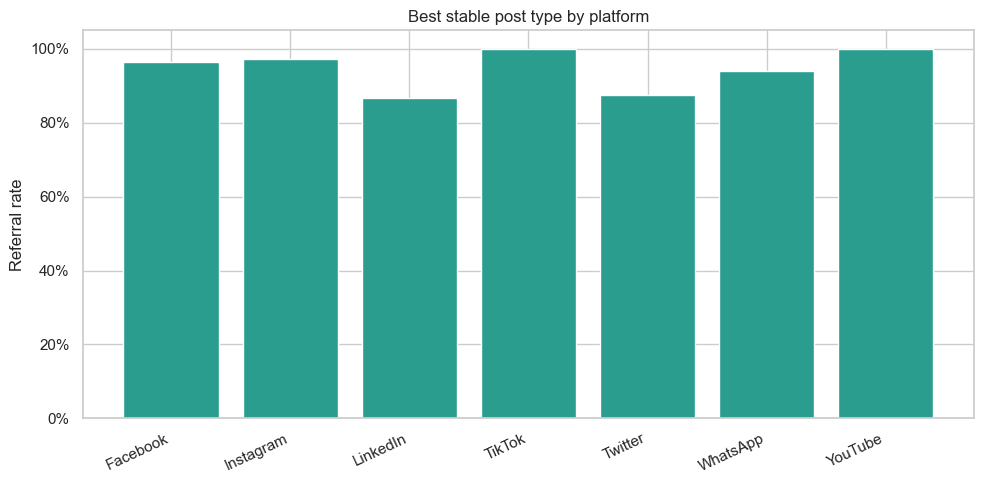

In [9]:
platform_post_type_summary = (
    posts.groupby(["platform", "post_type"]).agg(
        posts=("post_id", "size"),
        referral_rate=("has_referral", "mean"),
        avg_referrals=("donation_referrals", "mean"),
        avg_estimated_value_php=("estimated_donation_value_php", "mean"),
    )
    .reset_index()
)

stable_platform_post_type = (
    platform_post_type_summary.loc[platform_post_type_summary["posts"] >= 12]
    .copy()
    .sort_values(["referral_rate", "avg_estimated_value_php"], ascending=False)
)

best_post_type_by_platform = (
    stable_platform_post_type.sort_values(
        ["platform", "referral_rate", "avg_estimated_value_php"], ascending=[True, False, False]
    )
    .groupby("platform", as_index=False)
    .first()[["platform", "post_type", "posts", "referral_rate", "avg_referrals", "avg_estimated_value_php"]]
    .rename(columns={"post_type": "best_post_type"})
)

print("Best post type by platform, using only platform-post-type groups with at least 12 posts:")
display(best_post_type_by_platform.round(3))

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(best_post_type_by_platform["platform"], best_post_type_by_platform["referral_rate"], color="#2a9d8f")
ax.set_title("Best stable post type by platform")
ax.set_ylabel("Referral rate")
ax.set_ylim(0, 1.05)
ax.yaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


### What The Platform-Specific Analysis Adds

This new analysis gives the team a more tactical planning layer than the earlier whole-dataset summaries, while also being more careful about subgroup reliability.

Key patterns from the historical data:
- **Instagram:** `Reel` had the highest referral rate among stable and trusted subgroups, while `Carousel` was almost as strong and had the better average donation value. That means Instagram should usually lean toward reels for conversion probability and carousels when the team also cares about upside.
- **TikTok:** `Reel` clearly dominated on both referral rate and average donation value among trusted subgroup sizes, making it the strongest TikTok default.
- **Facebook:** `Video` performed best for referral rate, ahead of carousel, text, and photo posts.
- **YouTube:** `Video` remained the strongest trusted option and is the safer recommendation than the smaller `Reel` subgroup.
- **WhatsApp:** `Photo` became the safer recommendation once the notebook required a larger sample size. `Reel` looked extraordinary in the raw table, but it only had 7 posts, so it should be treated as promising rather than trusted.
- **Twitter and LinkedIn:** once the notebook applies a stricter sample-size filter, the best media recommendation becomes more conservative. That is exactly the point of the stability layer: it keeps the notebook from overclaiming based on thin data.
- **Post type still matters inside platforms:** `ImpactStory` remained the strongest repeated post type across many platforms, which means the platform recommendation should be paired with mission-centered creative rather than used alone.

This is exactly the kind of analysis staff can use in the Outreach planner: not just "which platform is good," but **which format tends to work best on that platform when there is enough evidence to trust it**.


## Evaluation and Interpretation

### What the predictive results mean in business terms
- The tuned random forest remains strong even under a stricter time-based holdout, which is more believable than a random split because it simulates predicting future posts.
- The model is best used as a **ranking tool** for planned posts, not as a rigid yes/no oracle.
- The threshold table now emphasizes a precision-oriented operating policy. In this use case, a false positive is more costly than a false negative because staff could waste time or budget pushing a weak post.
- The subgroup table is a lightweight fairness and reliability check. It shows whether the model behaves very differently across platforms and gives the team a place to keep monitoring performance after deployment.

### Recommended operating policy
- Use the predicted probability to rank candidate posts.
- Flag posts above `0.55` as likely referral drivers.
- Send the top-scoring drafts for final review, priority scheduling, or boost consideration.
- Keep monitoring platform-level error rates after deployment.

## Causal and Relationship Analysis

The PDF specifically requires causal and relationship analysis. This section uses an interpretable logistic regression as an **explanatory model**, not as proof of causal effects. The purpose is to estimate directional relationships and help the organization reason about content strategy while staying honest about the limitations of observational data.

In [10]:
explain_df = posts.copy()
explain_df["campaign_name"] = explain_df["campaign_name"].fillna("NoCampaign")
explain_df["call_to_action_type"] = explain_df["call_to_action_type"].fillna("NoCTA")
explain_df["boost_budget_php"] = explain_df["boost_budget_php"].fillna(0)

formula = (
    "has_referral ~ C(platform) + C(day_of_week) + post_hour + C(post_type) + C(media_type) + "
    "num_hashtags + has_call_to_action + C(call_to_action_type) + C(content_topic) + "
    "C(sentiment_tone) + caption_length + features_resident_story + C(campaign_name) + "
    "is_boosted + boost_budget_php"
)

logit_model = smf.logit(formula=formula, data=explain_df).fit(disp=False)
coef_table = pd.DataFrame(
    {
        "coefficient": logit_model.params,
        "odds_ratio": np.exp(logit_model.params),
        "p_value": logit_model.pvalues,
    }
).sort_values("p_value")

display(coef_table.head(20).round(4))

,coefficient,odds_ratio,p_value
post_hour,0.1705,1.1859,0.0000
C(post_type)[T.EventPromotion],-2.9248,0.0537,0.0000
C(post_type)[T.EducationalContent],-2.7993,0.0609,0.0000
C(post_type)[T.ThankYou],-2.8299,0.0590,0.0000
C(sentiment_tone)[T.Informative],-1.9958,0.1359,0.0000
features_resident_story[T.True],2.1127,8.2706,0.0043
C(content_topic)[T.CampaignLaunch],1.3557,3.8794,0.0100
C(platform)[T.LinkedIn],-0.9840,0.3738,0.0212
C(media_type)[T.Text],-0.9326,0.3935,0.0304
C(sentiment_tone)[T.Grateful],-0.8528,0.4262,0.0395


### Relationship discussion
- `post_hour` remains strongly positive in the explanatory model, suggesting later posting times were associated with stronger referral outcomes in this dataset.
- `features_resident_story` is strongly positive, which makes theoretical sense because story-centered content likely helps donors connect emotionally with the mission.
- Several post types such as `EventPromotion`, `EducationalContent`, and `ThankYou` underperform the baseline once other factors are held constant. Those formats may still be valuable for awareness, but they appear weaker for immediate donation referrals.
- The predictive model's top features and the explanatory model's strongest coefficients tell a consistent story: **what kind of post it is, when it is posted, and whether it centers a resident story matter more than cosmetic details**.
- Platform-media interactions matter in practice. The descriptive subgroup analysis suggests that **Reel** is especially strong on Instagram and TikTok, while **Video** is stronger on Facebook and YouTube.
- These platform-format results are operationally useful because they turn a generic recommendation like "use strong content" into a more specific one like "if you are posting on Instagram, start with reels or carousels, and if you are posting on Facebook, test video first."
- Small subgroup sizes can exaggerate results, so the notebook now uses explicit stability flags and a stricter trusted-recommendations threshold before declaring a format the best option on a platform.

### What I can and cannot claim
- I **can** claim these are meaningful conditional relationships in the observed data.
- I **cannot** claim that changing one feature will certainly cause more donations, because post assignment was not randomized and unobserved confounders may exist.
- I also **cannot** treat tiny subgroups as stable policy defaults, even when their observed referral rates look exceptional.
- This is why the notebook uses a predictive model for operations and an explanatory model for strategy, instead of pretending they answer the same question.


In [11]:
artifact_path = artifact_dir / "donation_referral_random_forest.joblib"
joblib.dump(best_model, artifact_path)

sample_scoring = X_test.head(5).copy()
sample_scoring = sample_scoring.assign(
    predicted_referral_probability=best_model.predict_proba(sample_scoring)[:, 1]
)

print("Saved predictive pipeline to:", artifact_path)
display(sample_scoring.sort_values("predicted_referral_probability", ascending=False))

Saved predictive pipeline to: /Users/jimmychurchill/Documents/Intex II/ml-pipelines/artifacts/donation_referral_random_forest.joblib


,platform,day_of_week,post_hour,post_type,media_type,num_hashtags,has_call_to_action,call_to_action_type,content_topic,sentiment_tone,caption_length,features_resident_story,campaign_name,is_boosted,boost_budget_php,predicted_referral_probability
649,Instagram,Friday,17,ImpactStory,Photo,2,False,NaN,Gratitude,Celebratory,142,True,NaN,True,1265.17,0.9875
653,Twitter,Saturday,17,Campaign,Photo,1,True,SignUp,Health,Urgent,176,False,NaN,False,NaN,0.8875
652,Facebook,Sunday,20,Campaign,Text,2,True,SignUp,Gratitude,Hopeful,178,False,NaN,False,NaN,0.8275
651,Instagram,Sunday,21,EducationalContent,Carousel,4,False,NaN,Education,Emotional,177,False,Back to School,False,NaN,0.6375
650,LinkedIn,Saturday,20,EventPromotion,Carousel,2,True,LearnMore,CampaignLaunch,Emotional,116,False,Back to School,False,NaN,0.5850


### Saved Model and Sample Predictions

This final code block is for deployment, not for feature testing.

It does two practical things:
- saves the trained model to a `.joblib` file
- shows a few sample predictions from unseen test posts

What the output means:
- each row is a test-set post
- `predicted_referral_probability` is the model's estimate that the post will generate at least one donation referral
- this is the same type of score the web app could use for future draft posts before publishing

## Deployment Notes

The PDF says a model that only exists in a notebook is not a complete pipeline, so the predictive artifact is saved to `ml-pipelines/artifacts/donation_referral_random_forest.joblib`.

### Intended web-app integration
1. Build a backend endpoint such as `POST /api/ml/social-post-referral-score`.
2. Send planned post metadata before publication.
3. Load the saved model artifact and return a referral probability.
4. Show the score inside a marketing planner, admin dashboard, or post-comparison tool.

### Example scoring snippet
```python
import joblib
import pandas as pd

model = joblib.load("ml-pipelines/artifacts/donation_referral_random_forest.joblib")

def score_planned_post(payload: dict) -> float:
    row = pd.DataFrame([payload])
    probability = model.predict_proba(row)[:, 1][0]
    return float(probability)
```

### Practical recommendation for the product team
- Use the probability score rather than a hard binary label whenever possible.
- Surface the top drivers from the notebook in the UI as guidance for content planning.
- Add a platform-specific planner card such as "Best format on Instagram" or "Best format on Facebook" using the subgroup tables from this notebook.
- Refit the model periodically as more posts are published so it stays current.

This notebook is fully executable top to bottom with repo-relative paths.